In [1]:
import io
import json
import math
import os
from datetime import datetime

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from PIL import Image
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
from visualizations import load_images_from_indices, visualize_attention, visualize_attention_on_images
from datasets import MNISTDataset, CIFAR10Dataset
from experiments import save_experiment, save_checkpoint
import logging

In [6]:
from model import ViTForClassfication

In [2]:
dataset = CIFAR10Dataset()

In [3]:
trainloader, testloader, _ = dataset.get_loaders(batch_size=32)

/Users/valefeve/Projects/interpretable-transformers/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
config = {
    "patch_size": 4,  # Input image size: 32x32 -> 8x8 patches
    "hidden_size": 48,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 4 * 48, # 4 * hidden_size
    "hidden_dropout_prob": 0.0,
    "attention_probs_dropout_prob": 0.0,
    "initializer_range": 0.02,
    "image_size": 32,
    "num_classes": 10, # num_classes of CIFAR10
    "num_channels": 3,
    "qkv_bias": True,
    "use_faster_attention": False,
}

In [7]:
model = ViTForClassfication(config).to('mps' if torch.backends.mps.is_available() else 'cpu')

In [8]:
model.load_state_dict(torch.load('vit_final_2026-04-15-17-36-04.pt', map_location='mps'))
model.eval()

ViTForClassfication(
  (embedding): Embeddings(
    (patch_embeddings): PatchEmbeddings(
      (projection): Conv2d(3, 48, kernel_size=(4, 4), stride=(4, 4))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Encoder(
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiHeadAttention(
          (heads): ModuleList(
            (0-3): 4 x AttentionHead(
              (query): Linear(in_features=48, out_features=12, bias=True)
              (key): Linear(in_features=48, out_features=12, bias=True)
              (value): Linear(in_features=48, out_features=12, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (output_projection): Linear(in_features=48, out_features=48, bias=True)
          (output_dropout): Dropout(p=0.0, inplace=False)
        )
        (layernorm_1): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=48, out_features=1

In [9]:
images = load_images_from_indices(testloader.dataset, [0, 1, 2, 3, 4, 5])
input_images = images.to('mps')
logits, attention_maps = model(images, output_attentions=True)

/Users/valefeve/Projects/interpretable-transformers/venv/lib/python3.11/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


In [11]:
attention_maps[-1].shape #Batch size x Num heads x Num patches x Num patches
target = attention_maps[-1][:, :, 0, 1:]
target.shape #Batch size x Num heads x Num patches-1

torch.Size([6, 4, 64])

In [12]:
print(f"Min attention value: {target.min().item():.4f}")
print(f"Max attention value: {target.max().item():.4f}")
print(f"Mean attention value: {target.mean().item():.4f}")

Min attention value: 0.0144
Max attention value: 0.0163
Mean attention value: 0.0154


In [33]:
import torch

torch.manual_seed(42)

# ── Stack 1: Concentrado ──────────────────────────────────────────────────────
# 6 grupos independientes; dentro de cada grupo, 4 filas = base + k*eps
eps = 0.01
groups_c = []
for _ in range(6):
    base = torch.rand(64)                              # vector base aleatorio
    rows = torch.stack([torch.clamp(base + k * eps, 0, 1)
                        for k in range(4)], dim=0)   # (4, 64)
    groups_c.append(rows)

stack_concentrated = torch.stack(groups_c, dim=0)       # (6, 4, 64)

# ── Stack 2: Disperso ─────────────────────────────────────────────────────────
# 6 grupos independientes; dentro de cada grupo, partición estricta en 4 filas
groups_d = []
for _ in range(6):
    assignment = torch.randint(0, 4, (64,))              # cada pos → fila 0,1,2 o 3
    values     = torch.rand(64)
    rows = torch.stack([torch.where(assignment == k, values,
                                   torch.zeros_like(values))
                        for k in range(4)], dim=0)   # (4, 64)
    groups_d.append(rows)

stack_dispersed = torch.stack(groups_d, dim=0)           # (6, 4, 64)

# ── Stack 3: Aleatorio puro ───────────────────────────────────────────────────
stack_random = torch.rand(6, 4, 64)                       # (6, 4, 64)

# ── Shapes ────────────────────────────────────────────────────────────────────
print(stack_concentrated.shape, stack_dispersed.shape, stack_random.shape)
# torch.Size([6, 4, 64])  torch.Size([6, 4, 64])  torch.Size([6, 4, 64])

torch.Size([6, 4, 64]) torch.Size([6, 4, 64]) torch.Size([6, 4, 64])


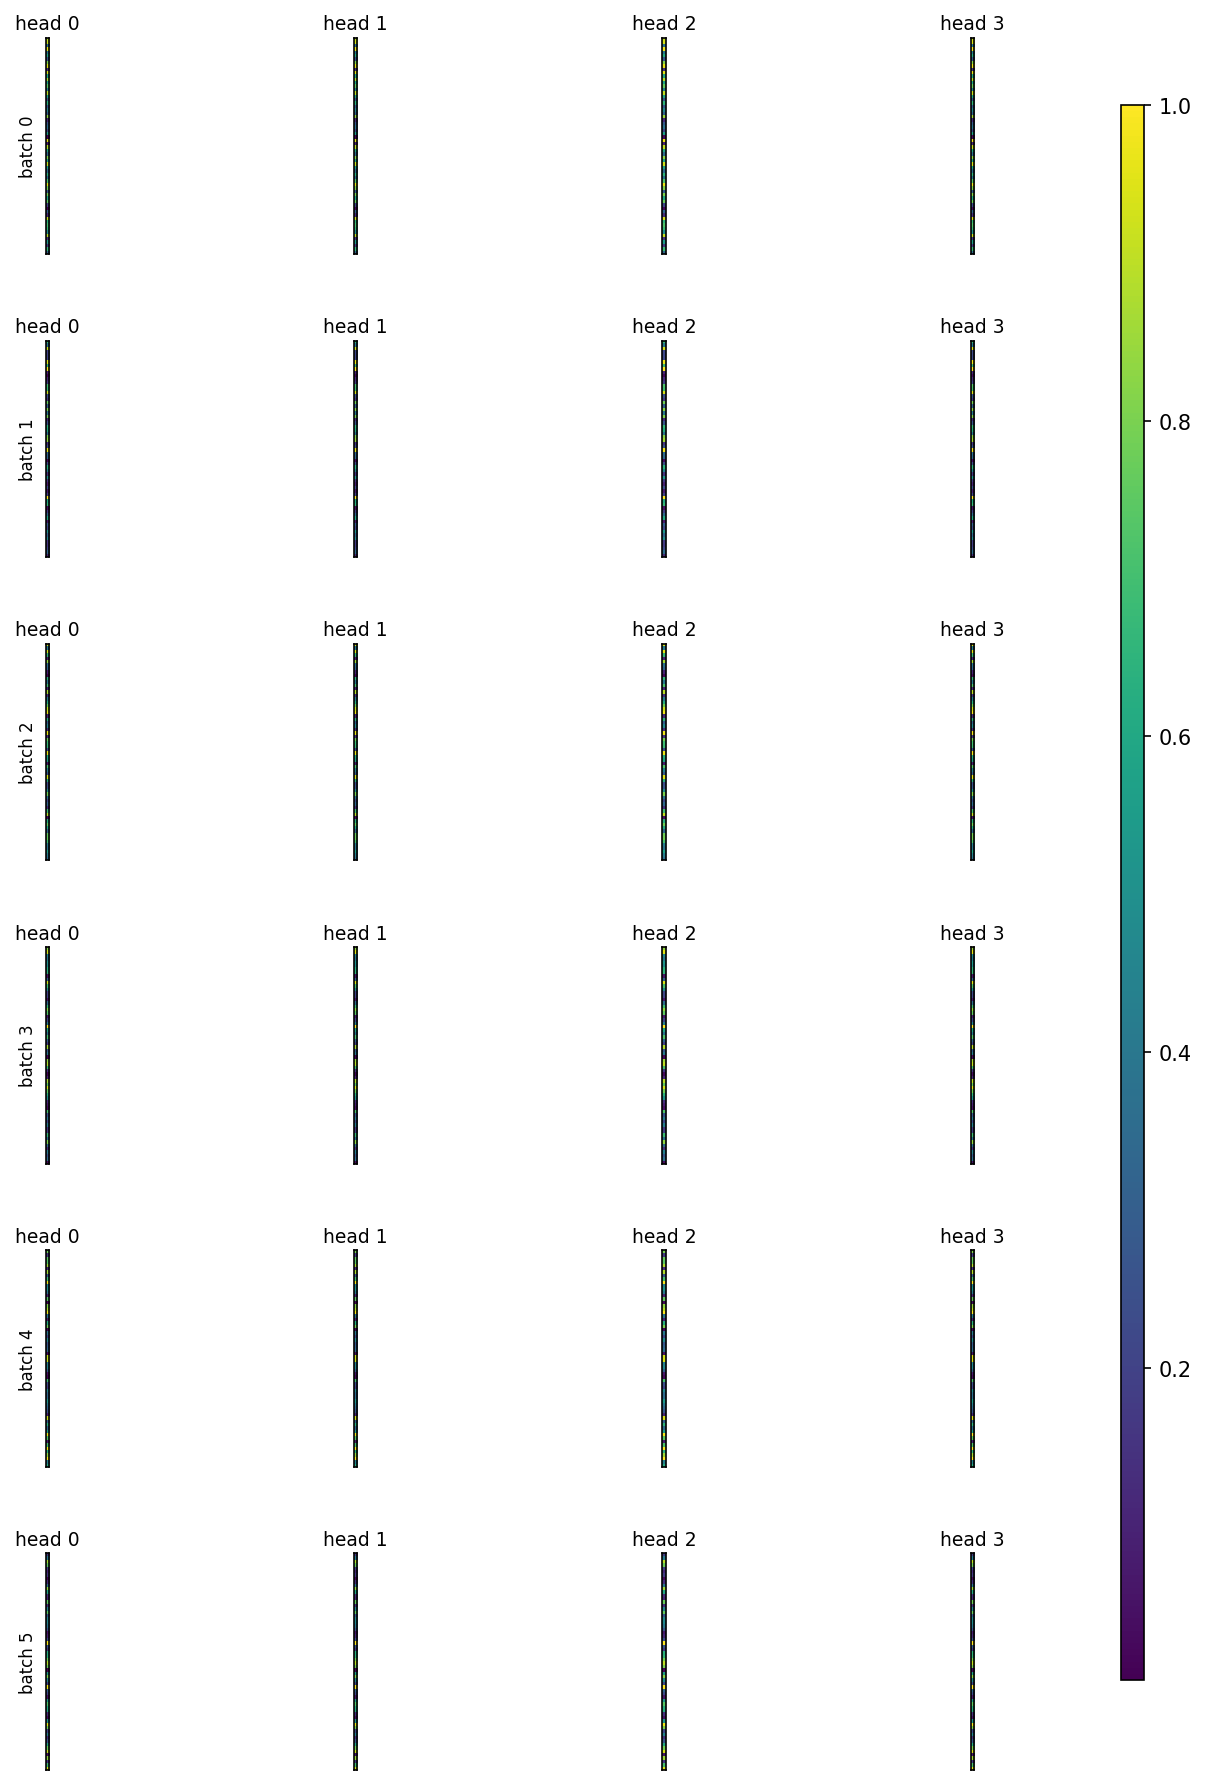

In [40]:
visualize_attention(stack_concentrated.unsqueeze(3))

In [46]:
stack_concentrated.shape # (6, 4, 64, 1)

torch.Size([6, 4, 64])

In [77]:
B, H, P = stack_dispersed.shape

In [ ]:
attention_maps = stack_dispersed  # (batch, heads, patches)
mm = torch.einsum('bhp,bkp->bhkp', attention_maps, attention_maps)
mm.shape

torch.Size([6, 4, 4, 64])

In [79]:
mm

tensor([[[[7.9532e-01, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 1.6822e-03],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00,

In [ ]:
# Máscara [H, H] → True en diagonal
diag_mask = torch.eye(H, dtype=torch.bool, device=attention_maps.device)

# Poner -inf en diagonal para que softmax la anule
mm_masked = mm.clone()
mm_masked[:, diag_mask, :] = float(0)

In [87]:
mm_masked.shape

torch.Size([6, 4, 4, 64])

In [88]:
mm_masked

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],

         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,

In [89]:
mm_sum = mm_masked.sum(dim=(1, 2))
mm_sum.shape

torch.Size([6, 64])

In [90]:
mm_sum

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.

In [91]:
mm_sum.sum(dim=1)

tensor([0., 0., 0., 0., 0., 0.])

In [75]:

softmax_bmm = F.softmax(mm_masked, dim=-1)  # Softmax over last dimension
softmax_bmm

tensor([[[0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         ...,
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156]],

        [[0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         ...,
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156]],

        [[0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.0156],
         [0.0156, 0.0156, 0.0156,  ..., 0.0156, 0.0156, 0.

In [51]:
attention_maps = stack_concentrated  # (batch, heads, patches)
bmm = torch.bmm(attention_maps, attention_maps.transpose(1, 2))
print(bmm.shape)
print(bmm)

torch.Size([6, 4, 4])
tensor([[[23.7873, 24.1342, 24.4811, 24.8280],
         [24.1342, 24.4875, 24.8409, 25.1942],
         [24.4811, 24.8409, 25.2006, 25.5603],
         [24.8280, 25.1942, 25.5603, 25.9264]],

        [[15.5950, 15.8418, 16.0874, 16.3243],
         [15.8418, 16.0950, 16.3469, 16.5899],
         [16.0874, 16.3469, 16.6050, 16.8542],
         [16.3243, 16.5899, 16.8542, 17.1097]],

        [[21.1414, 21.4628, 21.7843, 22.1057],
         [21.4628, 21.7907, 22.1185, 22.4464],
         [21.7843, 22.1185, 22.4528, 22.7870],
         [22.1057, 22.4464, 22.7870, 23.1277]],

        [[17.9860, 18.2715, 18.5533, 18.8289],
         [18.2715, 18.5633, 18.8515, 19.1334],
         [18.5533, 18.8515, 19.1460, 19.4343],
         [18.8289, 19.1334, 19.4343, 19.7288]],

        [[20.9926, 21.3026, 21.6055, 21.9011],
         [21.3026, 21.6188, 21.9280, 22.2299],
         [21.6055, 21.9280, 22.2436, 22.5516],
         [21.9011, 22.2299, 22.5516, 22.8659]],

        [[18.4666, 18.7512, 

In [42]:
# Apply eye mask to zero out diagonal (self-attention) and then softmax
eye_mask = torch.eye(bmm.size(1), device=bmm.device).unsqueeze(0)  # (1, heads, patches)
masked_bmm = bmm.masked_fill(eye_mask.bool(), float('-inf'))  # Zero out diagonal
softmax_bmm = F.softmax(masked_bmm, dim=-1)  # Softmax over last dimension
print(softmax_bmm)

tensor([[[0.0000, 0.2264, 0.3204, 0.4532],
         [0.1691, 0.0000, 0.3428, 0.4881],
         [0.1860, 0.2666, 0.0000, 0.5474],
         [0.2211, 0.3189, 0.4599, 0.0000]],

        [[0.0000, 0.2565, 0.3279, 0.4156],
         [0.2096, 0.0000, 0.3474, 0.4430],
         [0.2248, 0.2913, 0.0000, 0.4839],
         [0.2498, 0.3258, 0.4244, 0.0000]],

        [[0.0000, 0.2336, 0.3221, 0.4443],
         [0.1786, 0.0000, 0.3440, 0.4775],
         [0.1952, 0.2727, 0.0000, 0.5321],
         [0.2282, 0.3208, 0.4510, 0.0000]],

        [[0.0000, 0.2456, 0.3255, 0.4289],
         [0.1940, 0.0000, 0.3466, 0.4594],
         [0.2101, 0.2830, 0.0000, 0.5069],
         [0.2388, 0.3238, 0.4374, 0.0000]],

        [[0.0000, 0.2396, 0.3244, 0.4360],
         [0.1853, 0.0000, 0.3463, 0.4684],
         [0.2018, 0.2786, 0.0000, 0.5197],
         [0.2322, 0.3227, 0.4451, 0.0000]],

        [[0.0000, 0.2464, 0.3266, 0.4270],
         [0.1949, 0.0000, 0.3477, 0.4575],
         [0.2110, 0.2841, 0.0000, 0.5049],
 

In [44]:
entropy = -torch.sum(softmax_bmm * torch.log(softmax_bmm + 1e-10), dim=-1)  # (batch, heads)
entropy

tensor([[1.0597, 1.0176, 0.9952, 1.0554],
        [1.0795, 1.0555, 1.0461, 1.0756],
        [1.0650, 1.0277, 1.0090, 1.0610],
        [1.0733, 1.0427, 1.0294, 1.0688],
        [1.0695, 1.0349, 1.0191, 1.0643],
        [1.0740, 1.0438, 1.0309, 1.0689]])

In [45]:
loss = entropy.mean()
print(f"Loss: {loss.item():.4f}")

Loss: 1.0486


In [ ]:
def interpretability_loss(attention_maps):
    # attention_maps: (B, H, P)

    B, H, P = attention_maps.shape

    # Normalización L2 antes del producto punto entre cabezas.
    # Así la similitud queda en [-1, 1] (similitud coseno) y no depende de la magnitud
    # absoluta del vector de atención.
    attention_maps = F.normalize(attention_maps, p=2, dim=-1)

    # Producto punto entre todos los pares de cabezas
    mm = torch.einsum('bhp,bkp->bhkp', attention_maps, attention_maps)

    # Máscara [H, H] → True en diagonal
    diag_mask = torch.eye(H, dtype=torch.bool, device=attention_maps.device)

    # Anular la diagonal (no comparar cabeza consigo misma)
    mm_masked = mm.clone()
    mm_masked[:, diag_mask, :] = float(0)

    mm_sum = mm_masked.sum(dim=(1, 2))   # (B, P)
    mm_total = mm_sum.sum(dim=1)          # (B,)

    # Reducir a escalar para que .backward() funcione.
    return mm_total.mean()

In [116]:
print(f"Loss of concentrated attention: {interpretability_loss(stack_concentrated)}")
print(f"Loss of dispersed attention: {interpretability_loss(stack_dispersed)}")
print(f"Loss of random attention: {interpretability_loss(stack_random)}")

Loss of concentrated attention: tensor([298.0774, 196.0891, 265.4095, 226.1458, 263.0374, 231.8506])
Loss of dispersed attention: tensor([0., 0., 0., 0., 0., 0.])
Loss of random attention: tensor([197.4522, 193.0837, 204.0638, 193.6890, 160.9346, 195.0306])


In [240]:
def diversity_loss(attn):
    """
    attn: (batch, n_heads, n_tokens) — distribuciones de atención ya softmax
    
    Para cada cabeza i, calcula qué tan similar es a cada otra cabeza j
    usando el producto punto (análogo a tr(x·T) del paper).
    
    Luego pasa por softmax para obtener una "distribución de similitud"
    y penaliza cuando alguna cabeza j es muy similar a i.
    
    El loss total es la suma sobre todas las cabezas.
    """
    batch, n_heads, n_tokens = attn.shape
    
    # Producto punto entre todos los pares de cabezas
    # attn: (batch, n_heads, n_tokens)
    # similarity: (batch, n_heads, n_heads)
    similarity = torch.bmm(attn, attn.transpose(1, 2))  # x_i · x_j
    
    # Enmascarar la diagonal (no comparar cabeza consigo misma)
    mask = ~torch.eye(n_heads, dtype=torch.bool).unsqueeze(0)  # (1, n_heads, n_heads)
    
    # Para cada cabeza i, softmax sobre las similitudes con las demás
    # Esto es: exp(x_i · x_j) / sum_k≠i exp(x_i · x_k)
    sim_masked = similarity.masked_fill(~mask, float('-inf'))
    sim_softmax = F.softmax(sim_masked, dim=-1)  # (batch, n_heads, n_heads)
    
    # Si todas las cabezas fueran igualmente (dis)similares,
    # esta distribución sería uniforme → entropía máxima → bien
    # Si una cabeza j domina → entropía baja → mal → hay redundancia
    
    # Entropía de la distribución de similitud para cada cabeza
    # H(sim_i) = -sum_j p_ij * log(p_ij)
    log_sim = sim_softmax.clamp(min=1e-10).log()
    entropy_per_head = -(sim_softmax * log_sim).sum(dim=-1)  # (batch, n_heads)
    
    # Queremos MAXIMIZAR entropía → MINIMIZAR -entropía
    # Loss = -entropía promedio (sobre batch y cabezas)
    loss = -entropy_per_head.mean()
    
    return loss, {
        'similarity_matrix': similarity.mean(dim=0),       # (n_heads, n_heads) promedio
        'sim_softmax': sim_softmax.mean(dim=0),             # distribución de similitud promedio
        'entropy_per_head': entropy_per_head.mean(dim=0),   # entropía promedio por cabeza
        'loss': loss.item(),
    }

In [241]:
attention_maps[-1].shape

torch.Size([6, 4, 65, 65])

In [242]:
diversity_loss(attention_maps[-1][:, :, 0, 1:].to('cpu'))

(tensor(-1.0986, grad_fn=<NegBackward0>),
 {'similarity_matrix': tensor([[0.0152, 0.0151, 0.0152, 0.0151],
          [0.0151, 0.0151, 0.0151, 0.0151],
          [0.0152, 0.0151, 0.0152, 0.0151],
          [0.0151, 0.0151, 0.0151, 0.0151]], grad_fn=<MeanBackward1>),
  'sim_softmax': tensor([[0.0000, 0.3333, 0.3333, 0.3333],
          [0.3333, 0.0000, 0.3333, 0.3333],
          [0.3333, 0.3333, 0.0000, 0.3333],
          [0.3333, 0.3333, 0.3333, 0.0000]], grad_fn=<MeanBackward1>),
  'entropy_per_head': tensor([1.0986, 1.0986, 1.0986, 1.0986], grad_fn=<MeanBackward1>),
  'loss': -1.0986123085021973})

In [264]:
attn = attention_maps[-1][:, :, 0, 1:].to('cpu')
attn.shape

torch.Size([6, 4, 64])

In [265]:
# Describe attn
print(f"Shape of attn: {attn.shape}")  # (batch, n_heads, n_tokens)
print(f"Max value in attn: {attn.max().item():.4f}")
print(f"Min value in attn: {attn.min().item():.4f}")
print(f"Mean value in attn: {attn.mean().item():.4f}")

Shape of attn: torch.Size([6, 4, 64])
Max value in attn: 0.0163
Min value in attn: 0.0144
Mean value in attn: 0.0154


In [266]:
batch, n_heads, n_tokens = attn.shape


In [267]:
attn[0][1].sum()

tensor(0.9846, grad_fn=<SumBackward0>)

In [268]:
attn[0][0].sum()

tensor(0.9846, grad_fn=<SumBackward0>)

In [269]:
print(attn[0][0])
print(attn[0][1])

tensor([0.0151, 0.0152, 0.0152, 0.0153, 0.0152, 0.0153, 0.0153, 0.0152, 0.0152,
        0.0151, 0.0149, 0.0150, 0.0152, 0.0157, 0.0154, 0.0152, 0.0152, 0.0150,
        0.0157, 0.0154, 0.0153, 0.0154, 0.0155, 0.0152, 0.0153, 0.0153, 0.0150,
        0.0157, 0.0151, 0.0153, 0.0154, 0.0154, 0.0155, 0.0152, 0.0152, 0.0150,
        0.0154, 0.0155, 0.0151, 0.0152, 0.0157, 0.0151, 0.0155, 0.0156, 0.0161,
        0.0154, 0.0156, 0.0157, 0.0155, 0.0154, 0.0155, 0.0155, 0.0157, 0.0156,
        0.0159, 0.0156, 0.0156, 0.0154, 0.0156, 0.0154, 0.0157, 0.0156, 0.0155,
        0.0155], grad_fn=<SelectBackward0>)
tensor([0.0151, 0.0154, 0.0151, 0.0152, 0.0152, 0.0157, 0.0155, 0.0154, 0.0157,
        0.0153, 0.0156, 0.0155, 0.0155, 0.0150, 0.0157, 0.0156, 0.0146, 0.0154,
        0.0148, 0.0151, 0.0156, 0.0153, 0.0152, 0.0157, 0.0153, 0.0155, 0.0152,
        0.0150, 0.0150, 0.0150, 0.0155, 0.0154, 0.0150, 0.0151, 0.0153, 0.0151,
        0.0156, 0.0160, 0.0155, 0.0153, 0.0153, 0.0146, 0.0152, 0.0157, 0.01

In [270]:
attn.mean(dim=-1)

tensor([[0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154],
        [0.0154, 0.0154, 0.0154, 0.0154]], grad_fn=<MeanBackward1>)

In [271]:
u = attn - attn.mean(dim=-1, keepdim=True)
print(u)
print(u.mean())
print(u.min())
print(u.max())  

tensor([[[-2.5877e-04, -2.2601e-04, -2.2558e-04,  ...,  2.3635e-04,
           1.2255e-04,  1.5079e-04],
         [-2.4018e-04,  5.8312e-05, -2.4499e-04,  ...,  5.1958e-05,
          -2.0540e-04,  1.0613e-04],
         [ 3.5093e-05,  2.6687e-04,  2.4613e-04,  ..., -3.2607e-04,
           2.4834e-05, -3.5082e-04],
         [ 4.4817e-04,  4.3183e-04,  3.3336e-04,  ..., -2.1235e-04,
          -7.4265e-04, -2.2512e-04]],

        [[ 1.5018e-04,  1.8857e-04,  1.6890e-04,  ..., -1.1180e-04,
          -7.7110e-04, -1.3135e-05],
         [-3.0952e-04, -1.6856e-04, -2.5352e-04,  ..., -2.8679e-04,
          -9.9235e-04, -2.0777e-04],
         [ 2.3714e-04,  3.5805e-04,  3.6441e-04,  ..., -3.8469e-04,
          -2.4054e-04,  3.6234e-04],
         [-3.6760e-04, -3.3898e-04, -3.8666e-04,  ...,  3.7702e-04,
          -6.1275e-04, -2.2292e-04]],

        [[ 1.3179e-04,  1.5153e-04,  1.2627e-04,  ..., -1.7656e-04,
          -2.9903e-04, -2.5202e-04],
         [-4.5119e-04, -2.9478e-04, -3.7458e-04,  .

In [272]:
attn = F.relu(attn - attn.mean(dim=-1, keepdim=True))
#Normalizar para que siga siendo una distribución de probabilidad usando F.normalize
attn = F.normalize(attn, p=5, dim=-1)
print(attn)

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.3308, 0.1715, 0.2110],
         [0.0000, 0.0871, 0.0000,  ..., 0.0776, 0.0000, 0.1586],
         [0.0580, 0.4412, 0.4069,  ..., 0.0000, 0.0411, 0.0000],
         [0.5332, 0.5138, 0.3966,  ..., 0.0000, 0.0000, 0.0000]],

        [[0.3115, 0.3911, 0.3503,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.3283, 0.4957, 0.5045,  ..., 0.0000, 0.0000, 0.5016],
         [0.0000, 0.0000, 0.0000,  ..., 0.3456, 0.0000, 0.0000]],

        [[0.2501, 0.2875, 0.2396,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.1356, 0.0282, 0.2753],
         [0.0000, 0.4732, 0.5035,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.5630, 0.4357, 0.5439]],

        [[0.1472, 0.4310, 0.1733,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0160, 0.0000,  ..., 0.0000, 0.0000, 0.3248],
         [0.0809, 0.2235, 0.4384,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0

In [273]:

similarity = torch.bmm(attn, attn.transpose(1, 2))  # x_i · x_j
similarity

tensor([[[3.7066, 1.5328, 1.1600, 0.1647],
         [1.5328, 4.2848, 1.2778, 2.4174],
         [1.1600, 1.2778, 4.7063, 2.6154],
         [0.1647, 2.4174, 2.6154, 6.4794]],

        [[5.7866, 1.3772, 3.9974, 0.1267],
         [1.3772, 3.9717, 0.5644, 2.9810],
         [3.9974, 0.5644, 6.4868, 0.6659],
         [0.1267, 2.9810, 0.6659, 5.4593]],

        [[3.8951, 1.1601, 2.8477, 0.6932],
         [1.1601, 4.5660, 0.5598, 3.8038],
         [2.8477, 0.5598, 5.4337, 0.4448],
         [0.6932, 3.8038, 0.4448, 6.0133]],

        [[5.7615, 0.3701, 3.5839, 0.0128],
         [0.3701, 3.7135, 0.4815, 3.0480],
         [3.5839, 0.4815, 4.4501, 0.1797],
         [0.0128, 3.0480, 0.1797, 4.8678]],

        [[4.5873, 0.9574, 3.0140, 1.1822],
         [0.9574, 4.3631, 0.5294, 3.5268],
         [3.0140, 0.5294, 4.1243, 0.4032],
         [1.1822, 3.5268, 0.4032, 5.3878]],

        [[2.4129, 0.2696, 0.6205, 0.1891],
         [0.2696, 3.7452, 0.6961, 0.9951],
         [0.6205, 0.6961, 3.9597, 1.8689],
 

In [274]:

# Enmascarar la diagonal (no comparar cabeza consigo misma)
mask = ~torch.eye(n_heads, dtype=torch.bool).unsqueeze(0)  # (1, n_heads, n_heads)


In [275]:

# Para cada cabeza i, softmax sobre las similitudes con las demás
# Esto es: exp(x_i · x_j) / sum_k≠i exp(x_i · x_k)
sim_masked = similarity.masked_fill(~mask, 0)
sim_masked

tensor([[[0.0000, 1.5328, 1.1600, 0.1647],
         [1.5328, 0.0000, 1.2778, 2.4174],
         [1.1600, 1.2778, 0.0000, 2.6154],
         [0.1647, 2.4174, 2.6154, 0.0000]],

        [[0.0000, 1.3772, 3.9974, 0.1267],
         [1.3772, 0.0000, 0.5644, 2.9810],
         [3.9974, 0.5644, 0.0000, 0.6659],
         [0.1267, 2.9810, 0.6659, 0.0000]],

        [[0.0000, 1.1601, 2.8477, 0.6932],
         [1.1601, 0.0000, 0.5598, 3.8038],
         [2.8477, 0.5598, 0.0000, 0.4448],
         [0.6932, 3.8038, 0.4448, 0.0000]],

        [[0.0000, 0.3701, 3.5839, 0.0128],
         [0.3701, 0.0000, 0.4815, 3.0480],
         [3.5839, 0.4815, 0.0000, 0.1797],
         [0.0128, 3.0480, 0.1797, 0.0000]],

        [[0.0000, 0.9574, 3.0140, 1.1822],
         [0.9574, 0.0000, 0.5294, 3.5268],
         [3.0140, 0.5294, 0.0000, 0.4032],
         [1.1822, 3.5268, 0.4032, 0.0000]],

        [[0.0000, 0.2696, 0.6205, 0.1891],
         [0.2696, 0.0000, 0.6961, 0.9951],
         [0.6205, 0.6961, 0.0000, 1.8689],
 

In [276]:
sim_masked.shape

torch.Size([6, 4, 4])

In [277]:

sim_softmax = F.softmax(sim_masked, dim=-1)  # (batch, n_heads, n_heads)
sim_softmax.shape
sim_softmax

tensor([[[0.1000, 0.4631, 0.3190, 0.1179],
         [0.2266, 0.0489, 0.1756, 0.5489],
         [0.1487, 0.1673, 0.0466, 0.6374],
         [0.0436, 0.4144, 0.5051, 0.0369]],

        [[0.0165, 0.0655, 0.8993, 0.0187],
         [0.1500, 0.0378, 0.0665, 0.7457],
         [0.9205, 0.0297, 0.0169, 0.0329],
         [0.0477, 0.8284, 0.0818, 0.0420]],

        [[0.0427, 0.1361, 0.7359, 0.0853],
         [0.0628, 0.0197, 0.0344, 0.8831],
         [0.8000, 0.0812, 0.0464, 0.0724],
         [0.0405, 0.9077, 0.0316, 0.0202]],

        [[0.0253, 0.0367, 0.9123, 0.0257],
         [0.0576, 0.0398, 0.0644, 0.8382],
         [0.9042, 0.0406, 0.0251, 0.0301],
         [0.0417, 0.8678, 0.0493, 0.0412]],

        [[0.0367, 0.0956, 0.7479, 0.1198],
         [0.0663, 0.0254, 0.0432, 0.8651],
         [0.8292, 0.0691, 0.0407, 0.0609],
         [0.0820, 0.8552, 0.0376, 0.0251]],

        [[0.1860, 0.2435, 0.3459, 0.2247],
         [0.1865, 0.1424, 0.2857, 0.3853],
         [0.1639, 0.1768, 0.0881, 0.5712],
 

In [278]:

# Si todas las cabezas fueran igualmente (dis)similares,
# esta distribución sería uniforme → entropía máxima → bien
# Si una cabeza j domina → entropía baja → mal → hay redundancia

# Entropía de la distribución de similitud para cada cabeza
# H(sim_i) = -sum_j p_ij * log(p_ij)
log_sim = sim_softmax.clamp(min=1e-10).log()
entropy_per_head = -(sim_softmax * log_sim).sum(dim=-1)  # (batch, n_heads)
entropy_per_head

tensor([[1.2033, 1.1188, 1.0125, 0.9684],
        [0.4162, 0.8076, 0.3621, 0.6391],
        [0.8417, 0.4769, 0.7148, 0.4056],
        [0.3921, 0.6172, 0.4191, 0.5353],
        [0.8172, 0.5343, 0.6408, 0.5549],
        [1.3595, 1.3162, 1.1367, 1.1138]], grad_fn=<NegBackward0>)

In [279]:

# Queremos MAXIMIZAR entropía → MINIMIZAR -entropía
# Loss = -entropía promedio (sobre batch y cabezas)
loss = entropy_per_head.mean()


In [280]:
loss

tensor(0.7668, grad_fn=<MeanBackward0>)

In [260]:
def diversity_loss_gram(attn):
    """
    attn: (batch, n_heads, n_tokens) — distribuciones de atención ya softmax

    Mide diversidad entre cabezas usando el determinante de la matriz de Gram.

    El determinante captura el "volumen" que abarcan los vectores de atención
    como conjunto:
      - Cabezas diversas → apuntan en direcciones distintas → volumen grande → det grande
      - Cabezas redundantes → casi colineales → det cerca de cero

    Normalización coseno antes del dot product elimina el problema de escala
    que colapsaba el pipeline anterior (softmax+entropía sobre valores tiny).
    """
    batch, n_heads, n_tokens = attn.shape

    # Normalizar a norma unitaria: convierte dot product en similitud coseno
    # Ahora los valores están acotados en [-1, 1] independientemente de la escala
    attn_norm = F.normalize(attn, p=2, dim=-1)  # (batch, n_heads, n_tokens)

    # Matriz de Gram: similitud coseno entre todos los pares de cabezas
    # G[i,j] = cos(head_i, head_j) ∈ [-1, 1]
    G = torch.bmm(attn_norm, attn_norm.transpose(1, 2))  # (batch, n_heads, n_heads)

    # log-determinante: más estable numéricamente que det directo
    # slogdet devuelve (signo, log|det|) — usamos solo el log
    # Queremos MAXIMIZAR det(G) → MINIMIZAR -logdet
    sign, logdet = torch.linalg.slogdet(G)

    loss = -logdet.mean()

    # Similitud coseno promedio off-diagonal: interpretable directamente
    mask = ~torch.eye(n_heads, dtype=torch.bool, device=attn.device)
    mean_cos_sim = G[:, mask].mean().item()

    return loss, {
        'gram_matrix': G.mean(dim=0),          # (n_heads, n_heads) promedio sobre batch
        'logdet_per_sample': logdet,            # (batch,)
        'mean_logdet': logdet.mean().item(),
        'mean_cos_sim_offdiag': mean_cos_sim,  # 0 = ortogonales (máx diversidad), 1 = idénticas
        'loss': loss.item(),
    }

In [261]:
# Extraer atención del CLS token hacia los patches (última capa)
attn_raw = attention_maps[-1][:, :, 0, 1:].to('cpu')

loss_gram, info_gram = diversity_loss_gram(attn_raw)

print(f"Loss (Gram):          {info_gram['loss']:.4f}")
print(f"Mean log-det:         {info_gram['mean_logdet']:.4f}")
print(f"Mean cosine sim (off-diag): {info_gram['mean_cos_sim_offdiag']:.4f}")
print()
print("Gram matrix (promedio sobre batch):")
print(info_gram['gram_matrix'])

Loss (Gram):          24.0526
Mean log-det:         -24.0526
Mean cosine sim (off-diag): 0.9996

Gram matrix (promedio sobre batch):
tensor([[1.0000, 0.9998, 0.9998, 0.9995],
        [0.9998, 1.0000, 0.9995, 0.9998],
        [0.9998, 0.9995, 1.0000, 0.9993],
        [0.9995, 0.9998, 0.9993, 1.0000]], grad_fn=<MeanBackward1>)


In [262]:
# Comparar diversity_loss_gram por capa
# Permite ver si la redundancia está distribuida o concentrada en capas específicas
print(f"{'Capa':<8} {'logdet':>10} {'cos_sim':>10} {'loss':>10}")
print("-" * 42)
for i, attn_layer in enumerate(attention_maps):
    attn = attn_layer[:, :, 0, 1:].to('cpu')
    _, info = diversity_loss_gram(attn)
    print(f"Layer {i:<3} {info['mean_logdet']:>10.4f} {info['mean_cos_sim_offdiag']:>10.4f} {info['loss']:>10.4f}")

Capa         logdet    cos_sim       loss
------------------------------------------
Layer 0     -24.2385     0.9997    24.2385
Layer 1     -25.3577     0.9998    25.3577
Layer 2     -25.0833     0.9998    25.0833
Layer 3     -24.0526     0.9996    24.0526


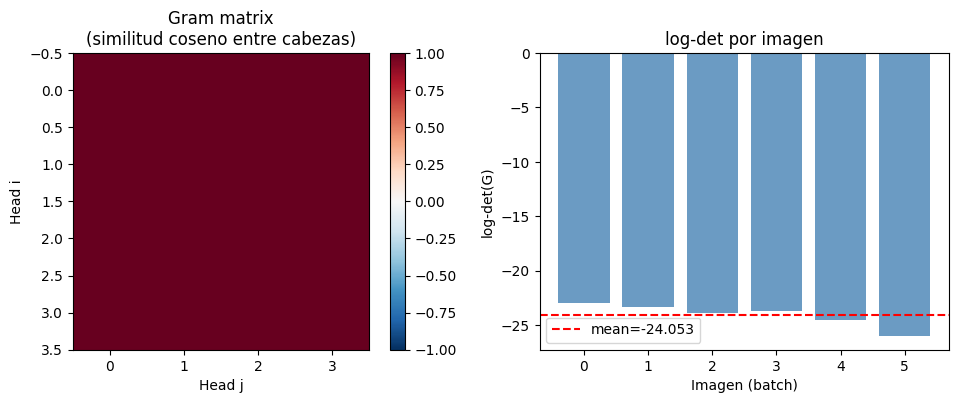

In [263]:
# Visualizar la Gram matrix de la última capa
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

G = info_gram['gram_matrix'].detach().numpy()

im0 = axes[0].imshow(G, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_title('Gram matrix\n(similitud coseno entre cabezas)')
axes[0].set_xlabel('Head j')
axes[0].set_ylabel('Head i')
plt.colorbar(im0, ax=axes[0])

# Heatmap de logdet por sample para ver variabilidad
logdets = info_gram['logdet_per_sample'].detach().numpy()
axes[1].bar(range(len(logdets)), logdets, color='steelblue', alpha=0.8)
axes[1].axhline(y=logdets.mean(), color='red', linestyle='--', label=f'mean={logdets.mean():.3f}')
axes[1].set_title('log-det por imagen')
axes[1].set_xlabel('Imagen (batch)')
axes[1].set_ylabel('log-det(G)')
axes[1].legend()

plt.tight_layout()
plt.show()

# `diversity_loss_on_outputs` para ViT

Hasta ahora las losses operan sobre **attention probabilities** — distribuciones sobre tokens.  
Esta función opera sobre los **outputs de cada cabeza** (la representación value-weighted, antes del concat y la proyección final), lo que mide diversidad en el espacio de representación, no en el espacio de atención.

Diferencia clave:
- `diversity_loss` → ¿las cabezas *miran* a lugares distintos?  
- `diversity_loss_on_outputs` → ¿las cabezas *producen representaciones* distintas?

En un ViT hay un detalle estructural importante: el token `[CLS]` no es espacial — agrega contexto global. Los patch tokens sí tienen estructura espacial. Controlamos qué tokens incluir con el parámetro `tokens`.

**Para extraer los outputs de cada cabeza sin modificar `model.py`** usamos PyTorch forward hooks sobre cada `AttentionHead` de la capa target.

In [ ]:
def capture_head_outputs(model, x, layer_idx=-1):
    """
    Captura los outputs de cada AttentionHead en la capa `layer_idx`
    usando forward hooks — sin modificar model.py.

    Retorna:
        head_outputs : (batch, n_heads, n_tokens, d_k)
            La representación value-weighted de cada cabeza ANTES del concat.
        attention_maps : list[Tensor]
            Los attention_probs de todas las capas (shape por capa: B, H, T, T).
    
    Nota: d_k = hidden_size / n_heads = 48 / 4 = 12 en este config.
          n_tokens = 65 (1 CLS + 64 patches para imagen 32x32 con patch_size=4).
    """
    captured = []

    # Seleccionar capa (soporta índices negativos)
    blocks = model.encoder.blocks
    layer = blocks[layer_idx]

    hooks = []
    for head in layer.attention.heads:
        # Necesitamos una closure para evitar que todas las hooks apunten
        # a la misma variable `head` al final del loop.
        def make_hook():
            def hook(module, input, output):
                # output = (attention_output, attention_probs)
                # attention_output : (batch, n_tokens, d_k)
                captured.append(output[0].detach())
            return hook
        hooks.append(head.register_forward_hook(make_hook()))

    with torch.no_grad():
        logits, attention_maps = model(x, output_attentions=True)

    # Limpiar hooks inmediatamente
    for h in hooks:
        h.remove()

    # captured: lista de n_heads tensores (batch, n_tokens, d_k)
    # → stack dim=1 → (batch, n_heads, n_tokens, d_k)
    head_outputs = torch.stack(captured, dim=1)
    return head_outputs, attention_maps


# Verificar shapes con el modelo cargado
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
images = load_images_from_indices(testloader.dataset, [0, 1, 2, 3, 4, 5])
input_images = images.to(device)

head_outputs, attention_maps = capture_head_outputs(model, input_images, layer_idx=-1)
print(f"head_outputs shape : {head_outputs.shape}")
# Esperado: (6, 4, 65, 12)  →  (batch=6, n_heads=4, n_tokens=65, d_k=12)
print(f"  batch={head_outputs.shape[0]}, n_heads={head_outputs.shape[1]}, "
      f"n_tokens={head_outputs.shape[2]} (1 CLS + 64 patches), d_k={head_outputs.shape[3]}")

In [ ]:
def diversity_loss_on_outputs(head_outputs, tokens='patches'):
    """
    Mide diversidad entre cabezas de atención en el espacio de representación
    (outputs value-weighted), no en el espacio de probabilidades de atención.

    Args:
        head_outputs : (batch, n_heads, n_tokens, d_k)
            Outputs de cada cabeza ANTES del concat + proyección final.
            Capturar con `capture_head_outputs`.
        tokens : str
            Qué tokens incluir en el análisis:
            - 'patches' (default): solo tokens espaciales [1:], excluye CLS.
              Mide si las cabezas detectan *patrones visuales* distintos.
            - 'cls': solo el token [CLS] (posición 0).
              Mide si las cabezas contribuyen de forma distinta a la clasificación.
            - 'all': todos los tokens incluyendo CLS.

    Returns:
        loss  : escalar — media de similitudes coseno al cuadrado (off-diagonal).
                Minimizar = forzar ortogonalidad entre representaciones de cabezas.
        info  : dict con métricas interpretables.

    Intuición geométrica:
        Centramos cada cabeza (quitamos bias de activación), promediamos sobre tokens
        para obtener una "firma" por cabeza, normalizamos a la esfera unitaria, y
        medimos similitud coseno entre pares. Loss = ||Gram - I||_F² (solo off-diag).
        Equivalente a empujar las cabezas hacia vectores ortogonales en R^d_k.
    """
    batch, n_heads, n_tokens, d_k = head_outputs.shape

    # --- 1. Selección de tokens según contexto ViT ---
    if tokens == 'patches':
        h = head_outputs[:, :, 1:, :]   # (B, H, 64, d_k) — solo patches espaciales
    elif tokens == 'cls':
        h = head_outputs[:, :, :1, :]   # (B, H, 1,  d_k) — solo CLS
    else:  # 'all'
        h = head_outputs                 # (B, H, 65, d_k)

    # --- 2. Centrar por dimensión d_k (quitar bias de activación por token) ---
    h = h - h.mean(dim=-1, keepdim=True)  # (B, H, T', d_k)

    # --- 3. Promediar sobre tokens → representación media de cada cabeza ---
    # Alternativa más robusta que flatten: reduce varianza sin perder señal.
    h_mean = h.mean(dim=2)  # (B, H, d_k)

    # --- 4. Normalizar a la esfera unitaria ---
    # Producto punto → similitud coseno. Elimina diferencias de escala.
    h_norm = F.normalize(h_mean, p=2, dim=-1)  # (B, H, d_k)

    # --- 5. Matriz de similitud coseno entre cabezas ---
    # G[b, i, j] = cos(head_i, head_j) para el sample b
    similarity = torch.bmm(h_norm, h_norm.transpose(1, 2))  # (B, H, H)

    # --- 6. Solo pares off-diagonal (i ≠ j) ---
    mask = ~torch.eye(n_heads, dtype=torch.bool, device=head_outputs.device)
    off_diag = similarity[:, mask]  # (B, H*(H-1))

    # --- 7. Loss = similitud cuadrática media ---
    # Penaliza redundancia directamente. Equivale a minimizar ||G - I||_F.
    loss = (off_diag ** 2).mean()

    return loss, {
        'similarity_matrix': similarity.mean(dim=0),        # (H, H) promedio sobre batch
        'mean_off_diag_sim': off_diag.abs().mean().item(),  # 0=ortogonales, 1=idénticas
        'max_off_diag_sim':  off_diag.abs().max().item(),   # par más redundante
        'loss': loss.item(),
        'tokens_used': tokens,
        'n_tokens_used': h.shape[2],
    }


# --- Prueba rápida ---
ho_cpu = head_outputs.cpu()
loss_out, info_out = diversity_loss_on_outputs(ho_cpu, tokens='patches')

print(f"Loss (output diversity, patches): {info_out['loss']:.4f}")
print(f"Mean |cosine sim| off-diag:       {info_out['mean_off_diag_sim']:.4f}")
print(f"Max  |cosine sim| off-diag:       {info_out['max_off_diag_sim']:.4f}")
print(f"Tokens usados:                    {info_out['n_tokens_used']} (patches)")
print()
print("Similarity matrix (promedio batch):")
print(info_out['similarity_matrix'].numpy().round(3))

In [ ]:
# --- Análisis por capa: ¿dónde hay más redundancia en representaciones? ---
# Comparamos patches vs CLS para entender qué tipo de diversidad tiene el modelo.

print(f"{'Capa':<8} {'loss(patches)':>14} {'cos_sim(patches)':>17} {'loss(cls)':>10} {'cos_sim(cls)':>13}")
print("-" * 68)

n_layers = len(model.encoder.blocks)
for i in range(n_layers):
    ho_i, _ = capture_head_outputs(model, input_images, layer_idx=i)
    ho_i = ho_i.cpu()

    _, info_patches = diversity_loss_on_outputs(ho_i, tokens='patches')
    _, info_cls     = diversity_loss_on_outputs(ho_i, tokens='cls')

    print(f"Layer {i:<3} "
          f"{info_patches['loss']:>14.4f} "
          f"{info_patches['mean_off_diag_sim']:>17.4f} "
          f"{info_cls['loss']:>10.4f} "
          f"{info_cls['mean_off_diag_sim']:>13.4f}")

In [ ]:
# --- Visualización: similarity matrices por capa (tokens=patches) ---
# Cada celda (i, j) = cos(head_i, head_j) en el espacio de representación.
# Diagonal = 1 (trivial). Off-diagonal: cerca de 1 → cabezas redundantes.

fig, axes = plt.subplots(1, n_layers, figsize=(4 * n_layers, 4))
fig.suptitle('Similitud coseno entre heads (espacio de representación, patches)', fontsize=13)

for i in range(n_layers):
    ho_i, _ = capture_head_outputs(model, input_images, layer_idx=i)
    _, info = diversity_loss_on_outputs(ho_i.cpu(), tokens='patches')

    G = info['similarity_matrix'].detach().numpy()
    im = axes[i].imshow(G, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[i].set_title(
        f"Layer {i}\nloss={info['loss']:.3f} | sim={info['mean_off_diag_sim']:.3f}",
        fontsize=9
    )
    axes[i].set_xlabel('Head j', fontsize=8)
    axes[i].set_ylabel('Head i', fontsize=8)
    axes[i].set_xticks(range(G.shape[0]))
    axes[i].set_yticks(range(G.shape[0]))

    # Anotar valores en cada celda
    for row in range(G.shape[0]):
        for col in range(G.shape[1]):
            axes[i].text(col, row, f"{G[row, col]:.2f}",
                         ha='center', va='center', fontsize=7,
                         color='white' if abs(G[row, col]) > 0.5 else 'black')

plt.colorbar(im, ax=axes[-1], shrink=0.8, label='cos sim')
plt.tight_layout()
plt.show()


# --- Comparación rápida: ¿cuánto difiere la señal patches vs CLS? ---
print("\nDelta (mean_off_diag_sim patches - cls) por capa:")
print("Un delta positivo → más redundancia en patches que en CLS.\n")
for i in range(n_layers):
    ho_i, _ = capture_head_outputs(model, input_images, layer_idx=i)
    _, ip = diversity_loss_on_outputs(ho_i.cpu(), tokens='patches')
    _, ic = diversity_loss_on_outputs(ho_i.cpu(), tokens='cls')
    delta = ip['mean_off_diag_sim'] - ic['mean_off_diag_sim']
    print(f"  Layer {i}: patches={ip['mean_off_diag_sim']:.4f}  cls={ic['mean_off_diag_sim']:.4f}  Δ={delta:+.4f}")

## Uso en training

Para incorporar `diversity_loss_on_outputs` al loop de entrenamiento, hay dos opciones:

**Opción A — hook en cada batch (ligero):**
```python
# En train_epoch, antes del backward:
ho, _ = capture_head_outputs(model, images, layer_idx=-1)
loss_repr, _ = diversity_loss_on_outputs(ho, tokens='patches')
loss = (1 - lambda_repr) * loss_cls - lambda_repr * loss_repr
```

**Opción B — combinar con diversity_loss existente (sobre attn probs):**
```python
loss_attn, _ = diversity_loss(attention_maps[-1][:, :, 0, 1:])   # distribuciones
loss_repr, _ = diversity_loss_on_outputs(ho, tokens='patches')    # representaciones
loss = loss_cls - alpha * loss_attn - beta * loss_repr
```
Ambas señales son complementarias: una penaliza que las cabezas miren los mismos patches, la otra que produzcan las mismas representaciones.

> **Nota**: `capture_head_outputs` hace un segundo forward pass con hooks. Si el costo es inaceptable, la alternativa es modificar `MultiHeadAttention.forward` para que retorne también los head outputs.